In [1]:
import sentencepiece as spm
from sacrebleu.metrics import BLEU

In [2]:
def calculate_BLEU(ku_voca_size, en_voca_size, gold_path):
    hyp_path = f"outputs/test{ku_voca_size}k-{en_voca_size}k.hyp.en"
    print(f"hyp_path: {hyp_path}")
    spm_model_path = f"data/spm_bpe_EN_{en_voca_size}k.model"
    print(f"SentencePiece model path: {spm_model_path}")
    
    #1: gold
    with open(gold_path, encoding = "utf-8") as f_gold:
        gold = f_gold.read().splitlines()
        
    print("---Gold samples---")
    print(gold[:3])
    print("--------------------")
    print()
    #2: 翻訳結果 hyp
    with open(hyp_path, encoding = "utf-8") as f_hyp:
        hyp = f_hyp.read().splitlines()
        
    print("---Hyp samples---")
    print(hyp[:3])
    print("--------------------")
    print()
    #3: SentencePieceでdetokenize
    sp = spm.SentencePieceProcessor()
    sp.load(spm_model_path)

    detok_hyp = [
        sp.decode(line.strip().split())
        for line in hyp
    ]

    print("---Hypothesis sample after decode---")
    print(detok_hyp[:3])
    print("----------------------------------------")
    print()
    bleu = BLEU(tokenize="13a")
    score = bleu.corpus_score(detok_hyp, [gold])

    return score
    
    

    
    
    

In [3]:
print(calculate_BLEU(14, 14, "data/test.en"))

hyp_path: outputs/test14k-14k.hyp.en
SentencePiece model path: data/spm_bpe_EN_14k.model
---Gold samples---
["let's exchange bulls", 'it was a short stay.', 'do not tell lies, tell the truth.']
--------------------

---Hyp samples---
['▁the ▁chholiya ▁dance ▁which ▁is ▁a ▁very ▁boring .', '▁i ▁have ▁to ▁go ▁to ▁the ▁market .', '▁the ▁chholiya ▁dance ▁is ▁like ▁a ▁martial ▁dance ▁the ▁jhoda ▁dance .']
--------------------

---Hypothesis sample after decode---
['the chholiya dance which is a very boring.', 'i have to go to the market.', 'the chholiya dance is like a martial dance the jhoda dance.']
----------------------------------------

BLEU = 10.00 36.6/13.5/6.3/3.2 (BP = 1.000 ratio = 1.042 hyp_len = 4474 ref_len = 4294)


In [4]:
for ku_voca_size in [1, 2, 4, 6]:
    for en_voca_size in [1, 2, 4, 6]:
        print("ku:",ku_voca_size)
        print("en:", en_voca_size)
        print(calculate_BLEU(ku_voca_size, en_voca_size, "data/test.en"))
        print()

ku: 1
en: 1
hyp_path: outputs/test1k-1k.hyp.en
SentencePiece model path: data/spm_bpe_EN_1k.model
---Gold samples---
["let's exchange bulls", 'it was a short stay.', 'do not tell lies, tell the truth.']
--------------------

---Hyp samples---
["▁let ' s ▁run ▁away ▁from ▁the ▁wee k . ▁we ' ll ▁have ▁d ire ct ly ▁away .", "▁let ' s ▁go ▁and ▁come ▁back .", "▁no , ▁i ▁don ' t ▁re la x , ▁it ' s ▁not ▁re la x ing ."]
--------------------

---Hypothesis sample after decode---
["let's run away from the week. we'll have directly away.", "let's go and come back.", "no, i don't relax, it's not relaxing."]
----------------------------------------

BLEU = 10.66 41.8/16.2/7.3/3.6 (BP = 0.921 ratio = 0.924 hyp_len = 3967 ref_len = 4294)

ku: 1
en: 2
hyp_path: outputs/test1k-2k.hyp.en
SentencePiece model path: data/spm_bpe_EN_2k.model
---Gold samples---
["let's exchange bulls", 'it was a short stay.', 'do not tell lies, tell the truth.']
--------------------

---Hyp samples---
["▁let ' s ▁take ▁the

In [5]:
import io
from contextlib import redirect_stdout
from functools import lru_cache

import pandas as pd

@lru_cache(maxsize=None)
def calculate_bleu_score(ku_voca_size, en_voca_size, gold_path="data/test.en"):
    with redirect_stdout(io.StringIO()):
        return calculate_BLEU(ku_voca_size, en_voca_size, gold_path).score

def build_bleu_matrix(ku_sizes, en_sizes, gold_path="data/test.en"):
    bleu_df = pd.DataFrame(
        [
            [calculate_bleu_score(ku_size, en_size, gold_path) for ku_size in ku_sizes]
            for en_size in en_sizes
        ],
        index=[f"{en_size}k" for en_size in en_sizes],
        columns=[f"{ku_size}k" for ku_size in ku_sizes],
    ).round(2)
    bleu_df.index.name = "en"
    bleu_df.columns.name = "ku"
    return bleu_df

def show_bleu_heatmap(bleu_df):
    return (
        bleu_df.style
        .format("{:.2f}")
        .background_gradient(cmap="YlOrRd", axis=None)
        .set_caption("BLEU heatmap (rows=en, columns=ku)")
        .set_properties(**{"text-align": "center"})
        .set_table_styles([
            {"selector": "th", "props": [("text-align", "center")]},
        ])
    )

sizes = [1, 2, 4, 6, 8, 10]
bleu_df = build_bleu_matrix(sizes, sizes)
bleu_df["avg"] = bleu_df.mean(axis=1).round(2)
bleu_df.loc["avg"] = bleu_df.mean(axis=0).round(2)
show_bleu_heatmap(bleu_df)


ku,1k,2k,4k,6k,8k,10k,avg
en,,,,,,,
1k,10.66,11.19,11.61,10.30,11.41,10.02,10.86
2k,11.60,10.66,11.97,11.47,11.05,10.35,11.18
4k,11.76,11.53,11.25,12.38,11.40,9.48,11.30
6k,10.50,12.21,12.30,12.55,11.41,10.85,11.64
8k,10.82,11.90,12.44,11.42,11.18,10.96,11.45
10k,10.95,11.70,11.04,11.44,11.58,10.85,11.26
avg,11.05,11.53,11.77,11.59,11.34,10.42,11.28


In [6]:
from collections import Counter
from pathlib import Path

import yaml

SPECIAL_TOKENS = {"<unk>", "<s>", "</s>", "<pad>"}

def load_marian_vocab(vocab_path, exclude_special_tokens=False):
    with open(vocab_path, encoding="utf-8") as f:
        vocab_data = yaml.safe_load(f)

    vocab = set(vocab_data.keys())
    if exclude_special_tokens:
        vocab -= SPECIAL_TOKENS
    return vocab

def calc_unk_stats(corpus_path, vocab_path, exclude_special_tokens=False):
    vocab = load_marian_vocab(vocab_path, exclude_special_tokens=exclude_special_tokens)

    with open(corpus_path, encoding="utf-8") as f:
        tokens = f.read().split()

    token_counter = Counter(tokens)
    unk_counter = Counter(token for token in tokens if token not in vocab)

    total_tokens = len(tokens)
    total_types = len(token_counter)
    unk_token_count = sum(unk_counter.values())
    unk_type_count = len(unk_counter)

    return {
        "total_tokens": total_tokens,
        "total_types": total_types,
        "vocab_size": len(vocab),
        "unk_token_count": unk_token_count,
        "unk_token_rate": unk_token_count / total_tokens if total_tokens else 0.0,
        "unk_type_count": unk_type_count,
        "unk_type_rate": unk_type_count / total_types if total_types else 0.0,
        "top_unk_tokens": unk_counter.most_common(20),
        "unk_tokens": unk_counter,
    }

def summarize_unk_for_sizes(sizes, lang="en", exclude_special_tokens=False):
    results = {}
    summary_rows = []

    for size in sizes:
        corpus_path = Path(f"data/test{size}k.{lang}")
        vocab_path = Path(f"vocabs/vocab.{lang}{size}k.yml")

        if not corpus_path.exists() or not vocab_path.exists():
            print(f"skip: missing file for {size}k ({corpus_path}, {vocab_path})")
            continue

        stats = calc_unk_stats(
            corpus_path,
            vocab_path,
            exclude_special_tokens=exclude_special_tokens,
        )
        results[size] = stats

        summary_rows.append({
            "vocab_size_k": size,
            "total_tokens": stats["total_tokens"],
            "total_types": stats["total_types"],
            "vocab_size": stats["vocab_size"],
            "unk_token_count": stats["unk_token_count"],
            "unk_token_rate": stats["unk_token_rate"],
            "unk_type_count": stats["unk_type_count"],
            "unk_type_rate": stats["unk_type_rate"],
        })

        print(f"\n===== {lang} {size}k =====")
        print(f"corpus         : {corpus_path}")
        print(f"vocab          : {vocab_path}")
        print(f"total tokens   : {stats['total_tokens']}")
        print(f"total types    : {stats['total_types']}")
        print(f"vocab size     : {stats['vocab_size']}")
        print(f"UNK tokens     : {stats['unk_token_count']}")
        print(f"UNK token rate : {stats['unk_token_rate']:.4%}")
        print(f"UNK types      : {stats['unk_type_count']}")
        print(f"UNK type rate  : {stats['unk_type_rate']:.4%}")
        print("top UNK tokens :", stats["top_unk_tokens"])

    summary_df = pd.DataFrame(summary_rows).set_index("vocab_size_k")
    if not summary_df.empty:
        summary_df[["unk_token_rate", "unk_type_rate"]] = (
            summary_df[["unk_token_rate", "unk_type_rate"]] * 100
        ).round(2)
        summary_df = summary_df.rename(columns={
            "unk_token_rate": "unk_token_rate_%",
            "unk_type_rate": "unk_type_rate_%",
        })

    return results, summary_df

sizes = [1, 2, 4, 6, 8, 10, 12, 14]
unk_results_en, unk_summary_en = summarize_unk_for_sizes(sizes, lang="en")
unk_summary_en



===== en 1k =====
corpus         : data/test1k.en
vocab          : vocabs/vocab.en1k.yml
total tokens   : 6452
total types    : 840
vocab size     : 999
UNK tokens     : 26
UNK token rate : 0.4030%
UNK types      : 8
UNK type rate  : 0.9524%
top UNK tokens : [('on', 15), ('0', 3), ('1', 2), ('2', 2), ('5', 1), ('▁eve', 1), ('1975', 1), ('3', 1)]

===== en 2k =====
corpus         : data/test2k.en
vocab          : vocabs/vocab.en2k.yml
total tokens   : 5545
total types    : 1192
vocab size     : 1918
UNK tokens     : 18
UNK token rate : 0.3246%
UNK types      : 8
UNK type rate  : 0.6711%
top UNK tokens : [('on', 7), ('0', 3), ('1', 2), ('2', 2), ('5', 1), ('1975', 1), ('3', 1), ('no', 1)]

===== en 4k =====
corpus         : data/test4k.en
vocab          : vocabs/vocab.en4k.yml
total tokens   : 5004
total types    : 1342
vocab size     : 3628
UNK tokens     : 17
UNK token rate : 0.3397%
UNK types      : 11
UNK type rate  : 0.8197%
top UNK tokens : [('0', 3), ('on', 3), ('1', 2), ('2', 2)

,total_tokens,total_types,vocab_size,unk_token_count,unk_token_rate_%,unk_type_count,unk_type_rate_%
vocab_size_k,,,,,,,
1,6452,840,999,26,0.40,8,0.95
2,5545,1192,1918,18,0.32,8,0.67
4,5004,1342,3628,17,0.34,11,0.82
6,4828,1334,4897,35,0.72,29,2.17
8,4714,1313,5682,154,3.27,116,8.83
10,4675,1294,5551,255,5.45,185,14.30
12,4664,1298,5551,247,5.30,190,14.64
14,4654,1297,5551,240,5.16,189,14.57


In [7]:
_, unk_summary_ku = summarize_unk_for_sizes(sizes, lang = "ku")
unk_summary_ku


===== ku 1k =====
corpus         : data/test1k.ku
vocab          : vocabs/vocab.ku1k.yml
total tokens   : 6015
total types    : 866
vocab size     : 998
UNK tokens     : 28
UNK token rate : 0.4655%
UNK types      : 8
UNK type rate  : 0.9238%
top UNK tokens : [('on', 15), ('no', 7), ('5', 1), ('1', 1), ('0', 1), ('1975', 1), ('2', 1), ('3', 1)]

===== ku 2k =====
corpus         : data/test2k.ku
vocab          : vocabs/vocab.ku2k.yml
total tokens   : 5262
total types    : 1268
vocab size     : 1989
UNK tokens     : 23
UNK token rate : 0.4371%
UNK types      : 9
UNK type rate  : 0.7098%
top UNK tokens : [('on', 10), ('no', 6), ('5', 1), ('1', 1), ('0', 1), ('aada', 1), ('1975', 1), ('2', 1), ('3', 1)]

===== ku 4k =====
corpus         : data/test4k.ku
vocab          : vocabs/vocab.ku4k.yml
total tokens   : 4691
total types    : 1549
vocab size     : 3845
UNK tokens     : 21
UNK token rate : 0.4477%
UNK types      : 11
UNK type rate  : 0.7101%
top UNK tokens : [('no', 6), ('on', 6), ('lee

,total_tokens,total_types,vocab_size,unk_token_count,unk_token_rate_%,unk_type_count,unk_type_rate_%
vocab_size_k,,,,,,,
1,6015,866,998,28,0.47,8,0.92
2,5262,1268,1989,23,0.44,9,0.71
4,4691,1549,3845,21,0.45,11,0.71
6,4477,1601,5588,32,0.71,23,1.44
8,4390,1601,6985,48,1.09,40,2.50
10,4304,1622,8174,157,3.65,122,7.52
12,4276,1619,8254,376,8.79,248,15.32
14,4255,1632,8254,366,8.60,262,16.05


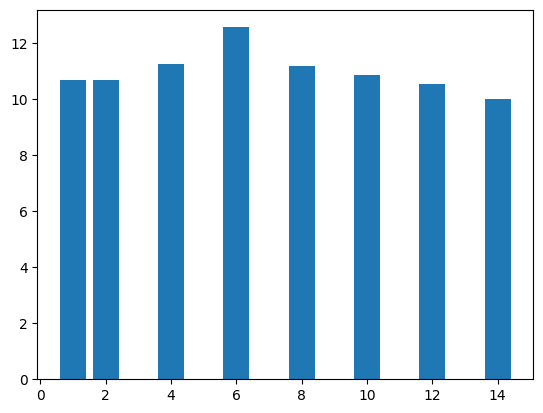

In [8]:
#vocabulary sizeがsrcとtgtで一致する時
import matplotlib.pyplot as plt
voca_size = [1, 2, 4, 6, 8, 10, 12, 14]
BLEU_score1 = [10.66, 10.66, 11.25, 12.55, 11.18, 10.85, 10.51,	10.00]
plt.bar(voca_size, BLEU_score1)
plt.show()

In [9]:
bleu_df
bleu_df["avg"] = bleu_df.mean(axis=1).round(2)
bleu_df.loc["avg"] = bleu_df.mean(axis=0).round(2)

In [10]:
bleu_df


ku,1k,2k,4k,6k,8k,10k,avg
en,,,,,,,
1k,10.66,11.19,11.61,10.30,11.41,10.02,10.86
2k,11.60,10.66,11.97,11.47,11.05,10.35,11.18
4k,11.76,11.53,11.25,12.38,11.40,9.48,11.30
6k,10.50,12.21,12.30,12.55,11.41,10.85,11.64
8k,10.82,11.90,12.44,11.42,11.18,10.96,11.45
10k,10.95,11.70,11.04,11.44,11.58,10.85,11.26
avg,11.05,11.53,11.77,11.59,11.34,10.42,11.28


In [11]:
show_bleu_heatmap(bleu_df)

ku,1k,2k,4k,6k,8k,10k,avg
en,,,,,,,
1k,10.66,11.19,11.61,10.30,11.41,10.02,10.86
2k,11.60,10.66,11.97,11.47,11.05,10.35,11.18
4k,11.76,11.53,11.25,12.38,11.40,9.48,11.30
6k,10.50,12.21,12.30,12.55,11.41,10.85,11.64
8k,10.82,11.90,12.44,11.42,11.18,10.96,11.45
10k,10.95,11.70,11.04,11.44,11.58,10.85,11.26
avg,11.05,11.53,11.77,11.59,11.34,10.42,11.28


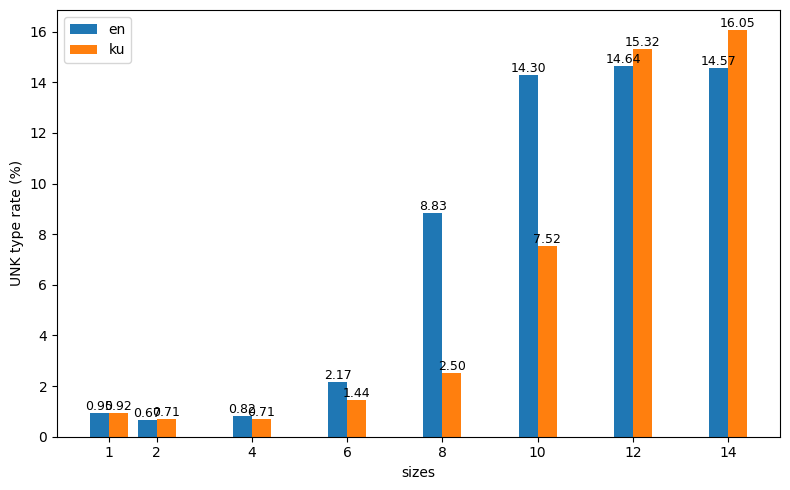

In [12]:
import matplotlib.pyplot as plt

sizes = unk_summary_en.index.tolist()
en_values = unk_summary_en["unk_type_rate_%"].tolist()
ku_values = unk_summary_ku["unk_type_rate_%"].tolist()

plt.figure(figsize=(8, 5))

bars_en = plt.bar([s - 0.2 for s in sizes], en_values, width=0.4, label="en")
bars_ku = plt.bar([s + 0.2 for s in sizes], ku_values, width=0.4, label="ku")

for bar in bars_en:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

for bar in bars_ku:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xlabel("sizes")
plt.ylabel("UNK type rate (%)")
#plt.title("UNK Type Rate by Vocabulary Size")
plt.xticks(sizes)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
def calculate_BLEU(layer, ku_voca_size, en_voca_size, gold_path):
    hyp_path = f"outputs/layer{layer}_test{ku_voca_size}k-{en_voca_size}k.hyp.en"
    print(f"hyp_path: {hyp_path}")
    spm_model_path = f"data/spm_bpe_EN_{en_voca_size}k.model"
    print(f"SentencePiece model path: {spm_model_path}")
    
    #1: gold
    with open(gold_path, encoding = "utf-8") as f_gold:
        gold = f_gold.read().splitlines()
        
    print("---Gold samples---")
    print(gold[:3])
    print("--------------------")
    print()
    #2: 翻訳結果 hyp
    with open(hyp_path, encoding = "utf-8") as f_hyp:
        hyp = f_hyp.read().splitlines()
        
    print("---Hyp samples---")
    print(hyp[:3])
    print("--------------------")
    print()
    #3: SentencePieceでdetokenize
    sp = spm.SentencePieceProcessor()
    sp.load(spm_model_path)

    detok_hyp = [
        sp.decode(line.strip().split())
        for line in hyp
    ]

    print("---Hypothesis sample after decode---")
    print(detok_hyp[:3])
    print("----------------------------------------")
    print()
    bleu = BLEU(tokenize="13a")
    score = bleu.corpus_score(detok_hyp, [gold])

    return score
    
    

    
    
    

In [14]:
layer_bleu =[]
layer_counts = [3, 4, 5, 6, 7, 8]
for layer_count in layer_counts:
    layer_bleu.append(calculate_BLEU(layer_count, 6, 6, "data/test.en"))

hyp_path: outputs/layer3_test6k-6k.hyp.en
SentencePiece model path: data/spm_bpe_EN_6k.model
---Gold samples---
["let's exchange bulls", 'it was a short stay.', 'do not tell lies, tell the truth.']
--------------------

---Hyp samples---
['▁they ▁make ▁a ▁temporary ▁seal ant ▁for ▁a ▁leaking ▁tap .', '▁please ▁go , ▁come ▁with ▁me .', '▁bl ind ▁person ▁is ▁not ▁true , ▁they ▁are ▁true .']
--------------------

---Hypothesis sample after decode---
['they make a temporary sealant for a leaking tap.', 'please go, come with me.', 'blind person is not true, they are true.']
----------------------------------------

hyp_path: outputs/layer4_test6k-6k.hyp.en
SentencePiece model path: data/spm_bpe_EN_6k.model
---Gold samples---
["let's exchange bulls", 'it was a short stay.', 'do not tell lies, tell the truth.']
--------------------

---Hyp samples---
["▁let ' s ▁take ▁a ▁temporary ▁shelter ▁from ▁the ▁top .", '▁come ▁to ▁meet ▁me .', '▁bl ind ▁person ▁is ▁not ▁said , ▁see ▁you .']
-----------

In [15]:
layer_bleu

[BLEU = 21.19 53.6/27.5/16.0/9.7 (BP = 0.969 ratio = 0.969 hyp_len = 4162 ref_len = 4294),
 BLEU = 18.79 51.8/25.7/13.8/7.6 (BP = 0.971 ratio = 0.972 hyp_len = 4172 ref_len = 4294),
 BLEU = 12.55 42.4/17.6/8.5/4.4 (BP = 0.970 ratio = 0.970 hyp_len = 4166 ref_len = 4294),
 BLEU = 11.22 40.8/15.8/7.4/3.7 (BP = 0.973 ratio = 0.973 hyp_len = 4180 ref_len = 4294),
 BLEU = 10.53 40.0/15.3/6.6/3.2 (BP = 0.990 ratio = 0.990 hyp_len = 4250 ref_len = 4294),
 BLEU = 9.39 40.6/14.2/6.0/3.2 (BP = 0.914 ratio = 0.918 hyp_len = 3940 ref_len = 4294)]

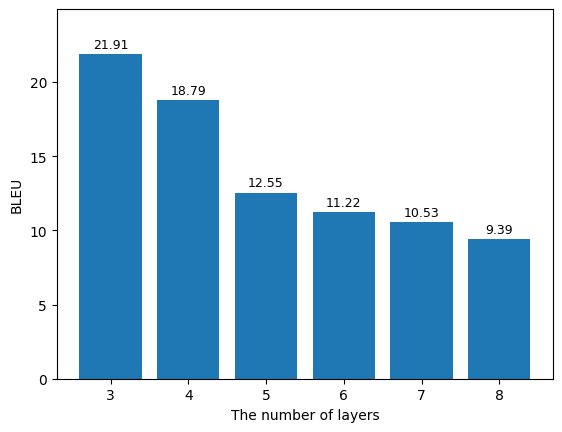

In [ ]:
import matplotlib.pyplot as plt

layer_counts = [3, 4, 5, 6, 7, 8]
bleu_scores = [21.91, 18.79, 12.55, 11.22, 10.53, 9.39]

bars = plt.bar(layer_counts, bleu_scores)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.2,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xlabel("The number of layers")
plt.ylabel("BLEU")
plt.xticks(layer_counts)
plt.ylim(0, max(bleu_scores) + 3)

plt.show()